# 03 — Temporal Analysis & Leakage

**Owner:** Bimsara's lane — timestamp/cycle analysis, event-window leakage study, split strategy.

This is the notebook Eval 1 is won or lost on (see `CLAUDE.md`). Output of this notebook: the final eligible-feature list and the split decision, handed off to notebook 04 (`preprocessing`).

Remember: every important choice gets a decision-log cell below it (what we decided, evidence, alternative considered, why rejected).

In [1]:
import sys
from pathlib import Path

# Jupyter's kernel CWD is notebooks/, so add the repo root to sys.path
# before importing anything from src/.
sys.path.append(str(Path.cwd().parent))

In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_STATE, FIGURES_DIR, PROCESSED_DATA_DIR
from src.pipeline import load_data

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = load_data()
df = df.sort_values("Timestamp").reset_index(drop=True)
df.shape

(7409, 24)

## Cycle stats

TODO: rows per cycle (plan expects 11-102, median ~25), reading cadence (~1/sec), and locate the ~5 hour gap between 08:17 and 15:36 on 26 Oct 2022.

In [4]:
df.groupby("cycle").size().describe()

count    240.000000
mean      30.870833
std       12.902433
min       11.000000
25%       24.000000
50%       25.000000
75%       30.000000
max      102.000000
dtype: float64

In [5]:
# TODO: confirm the reading cadence and locate the large gap
df["Timestamp"].diff().describe()

count                         7408
mean     0 days 00:00:03.553554670
std      0 days 00:03:38.580161805
min         0 days 00:00:00.984000
25%         0 days 00:00:01.003000
50%         0 days 00:00:01.005000
75%         0 days 00:00:01.007000
max         0 days 05:13:34.125000
Name: Timestamp, dtype: object

## Stop episodes

TODO: group consecutive `Robot_ProtectiveStop == 1` rows into episodes. Plan expects 278 stop rows -> 108 episodes (median 2 rows, max 12), occurring in 78 of 240 cycles. Confirm and adjust if the raw numbers differ.

In [6]:
is_stop = df["Robot_ProtectiveStop"] == 1
episode_id = (is_stop != is_stop.shift()).cumsum()
episodes = df[is_stop].groupby(episode_id[is_stop]).size()
print("stop rows:", is_stop.sum())
print("episodes:", episodes.shape[0])
episodes.describe()

stop rows: 278
episodes: 108


count    108.000000
mean       2.574074
std        1.880563
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       12.000000
dtype: float64

## Timeline of stops

TODO: plot stop occurrences over the day's timeline. Save to `FIGURES_DIR / "fig03_stop_timeline.png"`.

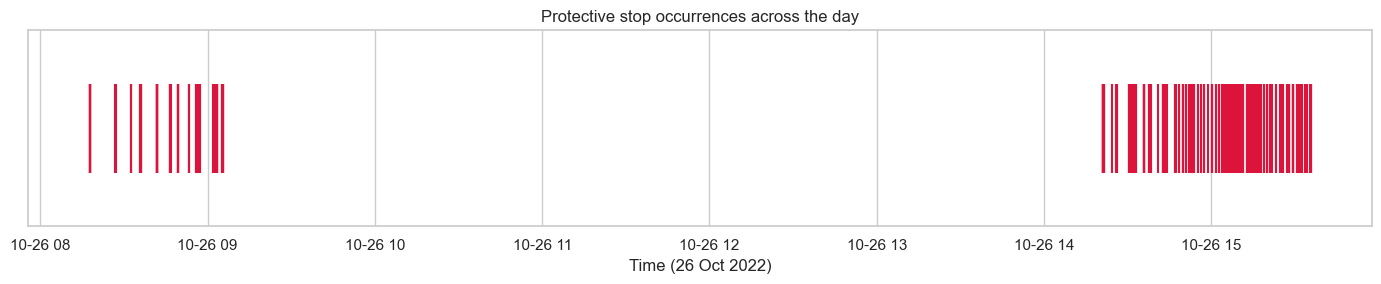

In [7]:
# TODO: timeline plot

fig, ax = plt.subplots(figsize=(14, 3))
stop_times = df.loc[df["Robot_ProtectiveStop"] == 1, "Timestamp"]
ax.eventplot(stop_times, lineoffsets=0, linelengths=0.8, color="crimson")
ax.set_yticks([])
ax.set_xlabel("Time (26 Oct 2022)")
ax.set_title("Protective stop occurrences across the day")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_stop_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


## Event-window leakage study (±10 rows around each stop)

TODO: for each stop episode, look at feature values from -10 to +10 rows around it. The plan's headline finding: median total joint speed is ~0.002 at stop rows vs ~0.056 at normal rows — same-row speed readings mostly describe a robot that has *already* stopped, not one about to stop. Confirm this and identify which other features carry the same same-row leakage.

In [8]:
speed_cols = [c for c in df.columns if c.startswith("Speed_J")]
# TODO: decide the aggregation (e.g. sum of abs, or L2 norm) and justify it in the decision log
df["total_joint_speed"] = df[speed_cols].abs().sum(axis=1)
df.groupby("Robot_ProtectiveStop")["total_joint_speed"].median()

Robot_ProtectiveStop
0.0    0.056224
1.0    0.002019
Name: total_joint_speed, dtype: float64

In [9]:
sensor_cols = [c for c in df.columns if c.startswith(("Current_", "Temperature_", "Tool_current"))]
df.groupby("Robot_ProtectiveStop")[sensor_cols].median().T

Robot_ProtectiveStop,0.0,1.0
Current_J0,-0.083452,-0.020977
Temperature_T0,36.500000,36.937500
Current_J1,-2.221180,-2.822194
Temperature_J1,39.687500,39.937500
Current_J2,-1.060021,-1.613609
Temperature_J2,40.187500,40.312500
Current_J3,-0.562035,-0.993316
Temperature_J3,43.062500,43.125000
Current_J4,-0.014018,0.018759
Temperature_J4,45.062500,45.125000


In [10]:
current_cols = [c for c in df.columns if c.startswith("Current_")]
df["total_joint_current"] = df[current_cols].abs().sum(axis=1)
df.groupby("Robot_ProtectiveStop")["total_joint_current"].median()

Robot_ProtectiveStop
0.0    4.305680
1.0    5.989461
Name: total_joint_current, dtype: float64

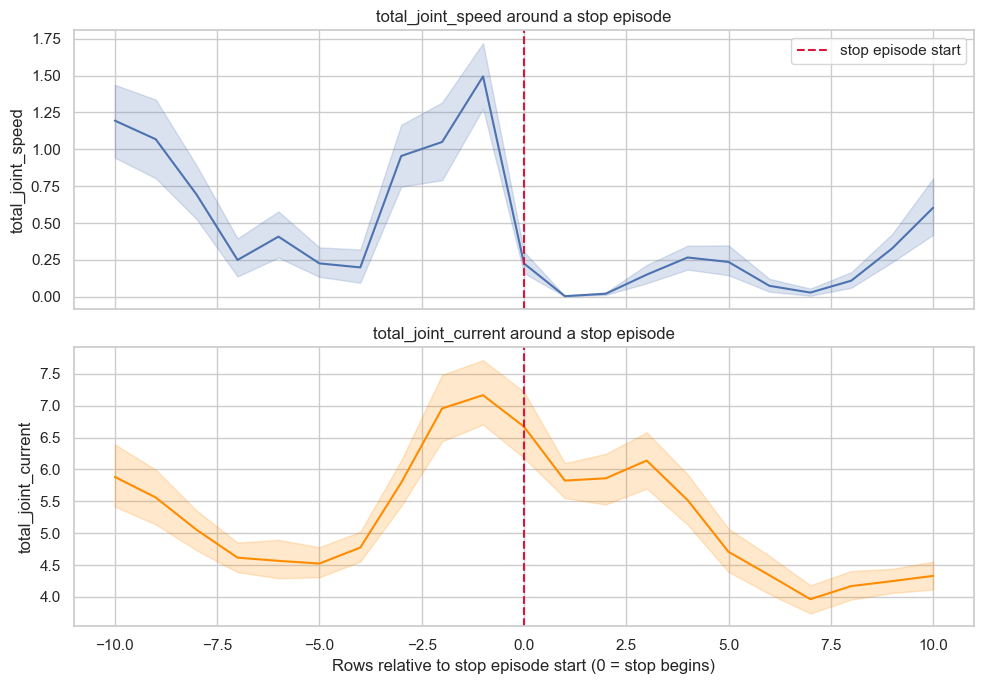

In [11]:
# TODO: build ±10-row windows around each stop episode and plot feature trajectories

window = 10
episode_starts = df[is_stop].groupby(episode_id[is_stop]).apply(lambda g: g.index[0])

records = []
for ep_start in episode_starts:
    lo, hi = max(ep_start - window, 0), min(ep_start + window, len(df) - 1)
    for idx in range(lo, hi + 1):
        records.append({
            "relative_row": idx - ep_start,
            "total_joint_speed": df.loc[idx, "total_joint_speed"],
            "total_joint_current": df.loc[idx, "total_joint_current"],
        })

window_df = pd.DataFrame(records)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
sns.lineplot(data=window_df, x="relative_row", y="total_joint_speed", ax=axes[0])
axes[0].axvline(0, color="crimson", linestyle="--", label="stop episode start")
axes[0].set_title("total_joint_speed around a stop episode")
axes[0].legend()

sns.lineplot(data=window_df, x="relative_row", y="total_joint_current", ax=axes[1], color="darkorange")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_title("total_joint_current around a stop episode")
axes[1].set_xlabel("Rows relative to stop episode start (0 = stop begins)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_event_window.png", dpi=150, bbox_inches="tight")
plt.show()


## grip_lost cross-tab

TODO: overlap between `grip_lost` and `Robot_ProtectiveStop`. Plan expects only 3 overlapping rows out of 243 grip-loss rows — confirm it is a weak predictor / separate event, not a leakage source.

In [12]:
pd.crosstab(df["grip_lost"], df["Robot_ProtectiveStop"])

Robot_ProtectiveStop,0.0,1.0
grip_lost,,
False,6837,275
True,240,3


## Final eligible-feature list

TODO: decide which raw/engineered features are safe to use (exclude same-row leakage features identified above, or redefine them using only prior-row/lagged values). This list is the handoff to notebook 04.

In [13]:
# TODO: fill in the final list once the leakage study above is done
ELIGIBLE_FEATURES = [
    "Current_J0", "Current_J1", "Current_J2", "Current_J3", "Current_J4", "Current_J5",
    "Temperature_T0", "Temperature_J1", "Temperature_J2", "Temperature_J3", "Temperature_J4", "Temperature_J5",
    "Tool_current",
    "grip_lost",
]


with open(PROCESSED_DATA_DIR / "eligible_features.json", "w") as f:
    json.dump(ELIGIBLE_FEATURES, f, indent=2)

ELIGIBLE_FEATURES

['Current_J0',
 'Current_J1',
 'Current_J2',
 'Current_J3',
 'Current_J4',
 'Current_J5',
 'Temperature_T0',
 'Temperature_J1',
 'Temperature_J2',
 'Temperature_J3',
 'Temperature_J4',
 'Temperature_J5',
 'Tool_current',
 'grip_lost']

## Split strategy decision

TODO: decide and justify StratifiedGroupKFold-by-cycle vs a chronological split (open decision in `CLAUDE.md`). Save the split (train/test row indices or cycle assignments) to `data/processed/` so notebook 04 and every model notebook reuse the exact same split.

In [14]:
# TODO: split implementation, then persist 

# Order cycles by when they started
cycle_start = df.groupby("cycle")["Timestamp"].min().sort_values()

# Last ~20% of cycles (by time) become the test holdout
n_test_cycles = round(len(cycle_start) * 0.2)
test_cycles = cycle_start.iloc[-n_test_cycles:].index.tolist()
train_cycles = cycle_start.iloc[:-n_test_cycles].index.tolist()

train_df = df[df["cycle"].isin(train_cycles)].reset_index(drop=True)
test_df = df[df["cycle"].isin(test_cycles)].reset_index(drop=True)

print("train cycles:", len(train_cycles), "| train rows:", len(train_df))
print("test cycles:", len(test_cycles), "| test rows:", len(test_df))
print("train stop rate:", train_df["Robot_ProtectiveStop"].mean())
print("test stop rate:", test_df["Robot_ProtectiveStop"].mean())

# Save the split so notebook 04 (and everyone downstream) reuses the exact same cycles
split_info = {
    "strategy": "chronological_by_cycle_last_20pct_holdout",
    "train_cycles": train_cycles,
    "test_cycles": test_cycles,
}
with open(PROCESSED_DATA_DIR / "split_cycles.json", "w") as f:
    json.dump(split_info, f, indent=2)


train cycles: 192 | train rows: 5494
test cycles: 48 | test rows: 1915
train stop rate: 0.03108997805413314
test stop rate: 0.057233704292527825


## Decision log

### Decision: Exclude Speed_J0-J5 from the eligible-feature list; keep Current, Temperature, Tool_current, grip_lost
- **Evidence:** Median total_joint_speed is 0.056 at normal rows vs 0.002 at stop rows — a stopped robot has ~zero speed by definition, so same-row speed is circular, not predictive. Median total_joint_current is *higher* at stop rows (5.99 vs 4.31) — a real signal (motors working harder, plausibly from resistance/force that triggered the stop), not a tautology. Temperature and Tool_current show no meaningful difference between classes. grip_lost overlaps a stop on only 3/243 rows, so it's leakage-safe but weak.
- **Alternative considered:** Keep Speed_J0-J5 as features.
- **Why rejected:** Speed reads ~0 at stop rows purely because "stopped" means "not moving" — using it would let the model "cheat" by detecting the outcome rather than predicting it, and wouldn't generalize to actually predicting a stop before it happens.


### Decision: Chronological-by-cycle split (last 20% of cycles as test), StratifiedGroupKFold by cycle for CV within training
- **Evidence:** Ordering the 240 cycles by start time and holding out the last 48 (20%) gives 192 train cycles (5,494 rows, 3.11% stop rate) and 48 test cycles (1,915 rows, 5.72% stop rate) — both single-digit and in the same ballpark as the overall 3.78%, so the test set is representative and has enough positive examples (~109 stop rows) to evaluate on.
- **Alternative considered:** Pure StratifiedGroupKFold by cycle (random group assignment, ignoring time order); naive row-level chronological split.
- **Why rejected:** Random group assignment doesn't test whether the model generalizes to situations that happen *later* in time, which is the realistic deployment scenario for a safety system. Naive row-level chronological splitting can cut a single cycle across train and test, reintroducing the same cycle-level leakage risk this split is meant to avoid.


### Observation: total_joint_current rises in the rows before a stop, not just during it
- **Evidence:** The ±10-row event-window plot shows total_joint_current climbing from ~4.5 to ~7 starting around row -5 relative to stop onset, peaking near row -1/0 — this precedes the stop, unlike speed which only drops after it starts.
- **Implication:** This is a candidate early-warning signal (predicting a stop a few rows ahead), not just a same-row descriptive one. Relevant to the open "detection vs early warning" framing decision — worth raising with the team before 04 finalizes the feature set, since an early-warning framing might want a lagged/rolling version of current as an engineered feature.
- **Not yet decided:** which framing the team picks — this is evidence for the discussion, not a final call made here.

